# 01 - Data Download and Initial Inspection

## Purpose of this notebook

In this notebook, I build the first stage of the project: the market data pipeline.

The goal here is to:
- define the ETF universe for the strategy
- download historical price data
- extract the adjusted close prices
- clean and inspect the data
- save both daily and monthly datasets for later notebooks

This notebook is important because every later step in the project depends on having clean and reliable price data. Before building momentum signals, moving average filters, or volatility targeting rules, I first need to make sure the historical data is complete, organized, and easy to reuse.

## Files this notebook should create

By the end of this notebook, I want to save:
- `data/processed/daily_adj_close.csv`
- `data/processed/monthly_prices.csv`
- `data/processed/monthly_returns.csv`

## Main design choice in this notebook

For the first version of the project, I use a small universe of broad, liquid ETFs. These represent different parts of the market, such as U.S. equities, international equities, Treasuries, and gold. This keeps the system realistic and easier to interpret than starting with hundreds of individual stocks.

## 1. Import libraries

In this section, I import the Python libraries that will be used throughout the notebook.

### What this section is doing
These imports give me the tools to:
- work with tabular time-series data using `pandas`
- perform numerical calculations using `numpy`
- visualize price behavior using `matplotlib`
- download market data from Yahoo Finance using `yfinance`
- work with file paths in a clean way using `pathlib`

### What I can change later
- If I want more interactive charts later, I could use `plotly` instead of `matplotlib`
- If I switch data providers later, I may replace `yfinance` with another API
- The plotting style can also be changed later if I want more polished visuals

### What to expect
This section should run without printing anything important. If an import fails, it usually means the package is not installed in the project environment yet.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## 2. Define project settings

In this section, I define the main settings for the data pipeline.

### What this section is doing
Here I choose:
- the ETF universe
- the historical start date
- the file paths where raw and processed data will be saved

### ETF universe used in version 1
I start with the following ETFs:

- `SPY`: large-cap U.S. equities
- `QQQ`: large-cap U.S. growth / tech exposure
- `IWM`: U.S. small caps
- `EFA`: developed international equities
- `EEM`: emerging market equities
- `TLT`: long-duration U.S. Treasuries
- `IEF`: intermediate-duration U.S. Treasuries
- `GLD`: gold

This gives the strategy exposure to different asset classes and market regimes.

### What I can change later
- I can add or remove ETFs from `TICKERS`
- I can change `START_DATE` if I want a longer or shorter history
- I can also change the folder structure later if I want more separation between raw and processed files

### Why this matters
These choices shape the entire project. If the ETF universe changes, then the momentum rankings, trend filters, and portfolio behavior will also change.

In [21]:
TICKERS = ["SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "IEF", "GLD"]
START_DATE = "2005-01-01"
END_DATE = None  # None means use the latest available date

DATA_DIR = Path("../data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Tickers:", TICKERS)
print("Start date:", START_DATE)
print("Raw data folder:", RAW_DIR.resolve())
print("Processed data folder:", PROCESSED_DIR.resolve())

Tickers: ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'IEF', 'GLD']
Start date: 2005-01-01
Raw data folder: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data/raw
Processed data folder: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data/processed


## 4. Download historical data

In this section, I download historical ETF price data from Yahoo Finance.

### What this section is doing
The `yfinance` package downloads a dataframe that contains multiple fields, such as:
- Open
- High
- Low
- Close
- Adj Close
- Volume

For this project, the most important field for backtesting is usually `Adj Close`, because it adjusts for stock splits and distributions.

### Why I download the full dataset first
Even though I may only use adjusted close prices later, downloading the full dataset lets me:
- inspect the structure of the returned data
- verify that all tickers downloaded properly
- keep the raw download if I want to use volume or other fields later

### What I can change later
- `auto_adjust=False` can be changed if I want Yahoo Finance to pre-adjust the prices
- I can add `end=` with a fixed date if I want fully reproducible historical snapshots
- I can switch to another data provider later if I want higher-quality institutional-style data

### What to expect
I should see a dataframe with a multi-level column structure, where the first level is the price field and the second level is the ticker.

In [22]:
raw_data = yf.download(
    TICKERS,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False
)

raw_data.head()

Price       Adj Close                                                         \
Ticker            EEM        EFA        GLD        IEF        IWM        QQQ   
Date                                                                           
2005-01-03  14.562677  28.951866  43.020000  48.410713  48.275024  33.695381   
2005-01-04  14.114314  28.396852  42.740002  48.109287  47.240181  33.081181   
2005-01-05  13.941525  28.378651  42.669998  48.188850  46.295994  32.876431   
2005-01-06  13.932051  28.378651  42.150002  48.234386  46.541466  32.714378   
2005-01-07  13.959026  28.251270  41.840000  48.194592  46.024055  32.884983   

Price                                 Close             ...        Open  \
Ticker            SPY        TLT        EEM        EFA  ...         SPY   
Date                                                    ...               
2005-01-03  81.606010  44.738453  22.194445  53.033333  ...  121.559998   
2005-01-04  80.608803  44.269611  21.511110  52.016666  ...  120.459999   
2005-01-05  80.052544  44.506535  21.247778  51.983334  ...  118.739998   
2005-01-06  80.459557  44.536804  21.233334  51.983334  ...  118.440002   
2005-01-07  80.344238  44.637630  21.274445  51.750000  ...  118.970001   

Price                   Volume                                       \
Ticker            TLT      EEM      EFA      GLD      IEF       IWM   
Date                                                                  
2005-01-03  88.180000  4275000  5273700  4750400   323400  16062600   
2005-01-04  88.720001  4205700  2983800  3456800  1181000  27450000   
2005-01-05  87.989998  3006900  3143700  2033600   369000  29884200   
2005-01-06  88.290001  2268000  2673300  2556400   389100  23061200   
2005-01-07  88.760002  4920300  2475300  4492700   182400  20906200   

Price                                     
Ticker            QQQ       SPY      TLT  
Date                                      
2005-01-03  100970900  55748000  1168000  
2005-01-04  136623200  69167600  1935400  
2005-01-05  127925500  65667300  1094100  
2005-01-06  102934600  47814700  1057400  
2005-01-07  123104000  55847700   738700  

[5 rows x 48 columns]

## 5. Inspect the raw download

Before extracting the exact price series I want, I first inspect the downloaded dataframe.

### What this section is doing
This step helps me understand:
- what columns were returned
- whether all tickers are present
- whether the dataframe shape looks reasonable
- whether there are obvious download issues

### Why this matters
A lot of later bugs happen because the raw data was never checked carefully. If one ticker is missing or one field is empty, the whole backtest can become misleading.

### What I can change later
Nothing major here. This is mainly a sanity-check step that I should keep in every data notebook.

### What to expect
I should see:
- the shape of the dataset
- the column labels
- confirmation that the download contains all expected tickers

In [23]:
print("Shape of raw dataset:", raw_data.shape)
print("\nColumn levels:")
print(raw_data.columns)

print("\nFirst few rows:")
display(raw_data.head())

Shape of raw dataset: (5332, 48)

Column levels:
MultiIndex([('Adj Close', 'EEM'),
            ('Adj Close', 'EFA'),
            ('Adj Close', 'GLD'),
            ('Adj Close', 'IEF'),
            ('Adj Close', 'IWM'),
            ('Adj Close', 'QQQ'),
            ('Adj Close', 'SPY'),
            ('Adj Close', 'TLT'),
            (    'Close', 'EEM'),
            (    'Close', 'EFA'),
            (    'Close', 'GLD'),
            (    'Close', 'IEF'),
            (    'Close', 'IWM'),
            (    'Close', 'QQQ'),
            (    'Close', 'SPY'),
            (    'Close', 'TLT'),
            (     'High', 'EEM'),
            (     'High', 'EFA'),
            (     'High', 'GLD'),
            (     'High', 'IEF'),
            (     'High', 'IWM'),
            (     'High', 'QQQ'),
            (     'High', 'SPY'),
            (     'High', 'TLT'),
            (      'Low', 'EEM'),
            (      'Low', 'EFA'),
            (      'Low', 'GLD'),
            (      'Low', 'IEF'),

Price       Adj Close                                                         \
Ticker            EEM        EFA        GLD        IEF        IWM        QQQ   
Date                                                                           
2005-01-03  14.562677  28.951866  43.020000  48.410713  48.275024  33.695381   
2005-01-04  14.114314  28.396852  42.740002  48.109287  47.240181  33.081181   
2005-01-05  13.941525  28.378651  42.669998  48.188850  46.295994  32.876431   
2005-01-06  13.932051  28.378651  42.150002  48.234386  46.541466  32.714378   
2005-01-07  13.959026  28.251270  41.840000  48.194592  46.024055  32.884983   

Price                                 Close             ...        Open  \
Ticker            SPY        TLT        EEM        EFA  ...         SPY   
Date                                                    ...               
2005-01-03  81.606010  44.738453  22.194445  53.033333  ...  121.559998   
2005-01-04  80.608803  44.269611  21.511110  52.016666  ...  120.459999   
2005-01-05  80.052544  44.506535  21.247778  51.983334  ...  118.739998   
2005-01-06  80.459557  44.536804  21.233334  51.983334  ...  118.440002   
2005-01-07  80.344238  44.637630  21.274445  51.750000  ...  118.970001   

Price                   Volume                                       \
Ticker            TLT      EEM      EFA      GLD      IEF       IWM   
Date                                                                  
2005-01-03  88.180000  4275000  5273700  4750400   323400  16062600   
2005-01-04  88.720001  4205700  2983800  3456800  1181000  27450000   
2005-01-05  87.989998  3006900  3143700  2033600   369000  29884200   
2005-01-06  88.290001  2268000  2673300  2556400   389100  23061200   
2005-01-07  88.760002  4920300  2475300  4492700   182400  20906200   

Price                                     
Ticker            QQQ       SPY      TLT  
Date                                      
2005-01-03  100970900  55748000  1168000  
2005-01-04  136623200  69167600  1935400  
2005-01-05  127925500  65667300  1094100  
2005-01-06  102934600  47814700  1057400  
2005-01-07  123104000  55847700   738700  

[5 rows x 48 columns]

## 6. Extract adjusted close prices

In this section, I extract the adjusted close prices from the raw dataset.

### What this section is doing
The adjusted close price is usually the best price series for backtesting long-only asset allocation strategies because it better reflects the true economic value of holding the asset over time.

### Why adjusted close matters
Raw closing prices can ignore important events like:
- stock splits
- ETF distributions
- dividend adjustments

Using adjusted close makes the time series more realistic for return calculations.

### What I can change later
- If I want to test execution assumptions, I may also use raw close or open prices later
- If I use another data provider, the field name may be slightly different
- If I move to intraday strategies later, adjusted close may not be enough on its own

### What to expect
This should create a dataframe where:
- each column is a ticker
- each row is a trading date
- each value is the adjusted close price for that ETF

In [24]:
adj_close = raw_data["Adj Close"].copy()
adj_close.head()

Ticker,EEM,EFA,GLD,IEF,IWM,QQQ,SPY,TLT
Date,,,,,,,,
2005-01-03,14.562677,28.951866,43.020000,48.410713,48.275024,33.695381,81.606010,44.738453
2005-01-04,14.114314,28.396852,42.740002,48.109287,47.240181,33.081181,80.608803,44.269611
2005-01-05,13.941525,28.378651,42.669998,48.188850,46.295994,32.876431,80.052544,44.506535
2005-01-06,13.932051,28.378651,42.150002,48.234386,46.541466,32.714378,80.459557,44.536804
2005-01-07,13.959026,28.251270,41.840000,48.194592,46.024055,32.884983,80.344238,44.637630


## 7. Check missing values

In this section, I check whether the adjusted close dataset has any missing values.

### What this section is doing
I count how many missing entries each ETF has. Missing values can happen for several reasons:
- an ETF started trading after the chosen start date
- Yahoo Finance returned incomplete data
- market holidays or alignment issues created gaps

### Why this matters
Missing values can break return calculations and distort momentum or moving average signals. I want to detect problems early instead of silently passing bad data into the model.

### What I can change later
- If I use a different universe, the missing-value pattern may change
- If a ticker has too much missing data, I may decide to remove it
- If I later use a younger ETF, I may need a later start date

### What to expect
I should see a count of missing values for each ticker. A small number may be okay, but a large amount needs investigation.

In [25]:
missing_counts = adj_close.isna().sum().sort_values(ascending=False)
missing_counts

Ticker
EEM    0
EFA    0
GLD    0
IEF    0
IWM    0
QQQ    0
SPY    0
TLT    0
dtype: int64

## 8. Clean the daily price data

In this section, I clean the adjusted close dataframe.

### What this section is doing
I:
1. sort the index by date
2. forward-fill missing values
3. drop any remaining rows with missing values

### Why this approach is reasonable
Forward-filling is acceptable for market prices when the missing values are small alignment gaps or non-trading mismatches. After that, I drop rows that still contain missing values so that the final dataset is complete.

### Important caution
This should be done carefully. I do not want to blindly fill large missing blocks without understanding why they happened.

### What I can change later
- I could choose to drop columns instead of rows if one ETF is the main problem
- I could use a later start date to reduce missing data from newer ETFs
- I could add more diagnostics if I want to inspect missing-value periods more deeply

### What to expect
The final cleaned dataframe should have:
- dates in order
- no missing values
- one price column per ETF

In [26]:
adj_close = adj_close.sort_index()
adj_close = adj_close.ffill().dropna()

print("Any missing values left?", adj_close.isna().any().any())
print("Cleaned shape:", adj_close.shape)

adj_close.head()

Any missing values left? False
Cleaned shape: (5332, 8)


Ticker,EEM,EFA,GLD,IEF,IWM,QQQ,SPY,TLT
Date,,,,,,,,
2005-01-03,14.562677,28.951866,43.020000,48.410713,48.275024,33.695381,81.606010,44.738453
2005-01-04,14.114314,28.396852,42.740002,48.109287,47.240181,33.081181,80.608803,44.269611
2005-01-05,13.941525,28.378651,42.669998,48.188850,46.295994,32.876431,80.052544,44.506535
2005-01-06,13.932051,28.378651,42.150002,48.234386,46.541466,32.714378,80.459557,44.536804
2005-01-07,13.959026,28.251270,41.840000,48.194592,46.024055,32.884983,80.344238,44.637630


## 9. Save the cleaned daily data

In this section, I save the cleaned daily adjusted close prices to a CSV file.

### What this section is doing
This creates a reusable dataset that later notebooks can load directly, instead of re-downloading market data every time.

### Why this is useful
Saving processed data helps with:
- reproducibility
- faster workflow
- debugging
- keeping a consistent input for later analysis

### What I can change later
- I could save to Parquet instead of CSV for faster reads
- I could include a timestamp in the filename for versioned snapshots
- I could also save the raw download separately if I want a permanent record of the original API output

### What to expect
After this cell runs, I should have a file named:
`data/processed/daily_adj_close.csv`

In [27]:
daily_adj_close_path = PROCESSED_DIR / "daily_adj_close.csv"
adj_close.to_csv(daily_adj_close_path)

print(f"Saved cleaned daily adjusted close data to: {daily_adj_close_path.resolve()}")

Saved cleaned daily adjusted close data to: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data/processed/daily_adj_close.csv


## 10. Create month-end prices

In this section, I convert the daily adjusted close prices into month-end prices.

### What this section is doing
I resample the daily data to monthly frequency by taking the last available trading day of each business month.

I also check whether the final month in the dataset is incomplete. If the latest daily observation is not actually at month-end, I remove that final monthly row so that the monthly dataset only contains fully completed months.

### Why I am doing this
The first version of the strategy will likely rebalance monthly. Using completed month-end prices gives a cleaner and more realistic framework for backtesting.

If I leave an incomplete final month in the dataset, then:
- the latest monthly return will be partial
- momentum signals can be distorted
- the last row will not be comparable to earlier completed months

### Why business month-end is better
Using business month-end matches financial market data better than plain calendar month-end, since markets do not trade on weekends or holidays.

### What I can change later
- I can switch to weekly data if I want to test weekly rebalancing later
- I can keep partial-month data for live monitoring, but not for historical backtesting
- I can change the resampling frequency if I want a different strategy horizon

### What to expect
This should produce a monthly price dataframe with one row per completed business month and one column per ETF.

In [28]:
# Convert daily adjusted close prices to business month-end prices
monthly_prices = adj_close.resample("BM").last()

# Check whether the last available daily observation is part of an incomplete month
last_daily_date = adj_close.index.max()
last_monthly_label = monthly_prices.index.max()

# If the latest daily date is earlier than the business month-end label,
# then the final monthly row is incomplete and should be removed
if last_daily_date.date() < last_monthly_label.date():
    monthly_prices = monthly_prices.iloc[:-1]
    print(f"Dropped incomplete final month labeled {last_monthly_label.date()}")
else:
    print("Final month is complete")

print("Latest daily date:", last_daily_date.date())
print("Latest monthly date used:", monthly_prices.index.max().date())

monthly_prices.head()

Dropped incomplete final month labeled 2026-03-31
Latest daily date: 2026-03-13
Latest monthly date used: 2026-02-27


/var/folders/sx/02p4fzbd32gghvv7j9kwgb5m0000gn/T/ipykernel_73314/965081540.py:2: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  monthly_prices = adj_close.resample("BM").last()


Ticker,EEM,EFA,GLD,IEF,IWM,QQQ,SPY,TLT
Date,,,,,,,,
2005-01-31,14.637771,28.606121,42.220001,48.734882,46.922932,31.903990,80.154320,46.235783
2005-02-28,16.055035,29.688854,43.529999,48.067986,47.693409,31.750433,81.829826,45.555168
2005-03-31,14.785039,28.910019,42.820000,47.874046,46.341408,31.195953,80.332947,45.348000
2005-04-29,14.600583,28.442339,43.349998,49.078831,43.719868,29.839607,78.827843,47.100842
2005-05-31,15.062075,28.196678,41.650002,49.981003,46.546272,32.484039,81.368103,48.578629


## 11. Save monthly prices

In this section, I save the month-end ETF prices to a CSV file.

### What this section is doing
This creates the main price dataset that later signal notebooks will likely use for momentum ranking and monthly portfolio rebalancing.

### What I can change later
- I may later save weekly prices too if I want to compare rebalance frequencies
- I may also compute rolling features and save those in processed form

### What to expect
After this cell runs, I should have a file named:
`data/processed/monthly_prices.csv`

In [29]:
monthly_prices_path = PROCESSED_DIR / "monthly_prices.csv"
monthly_prices.to_csv(monthly_prices_path)

print(f"Saved monthly prices to: {monthly_prices_path.resolve()}")

Saved monthly prices to: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data/processed/monthly_prices.csv


## 12. Compute monthly returns

In this section, I calculate monthly percentage returns from the month-end price data.

### What this section is doing
I use percentage change to convert monthly prices into returns. Returns are the main input for momentum calculations, volatility estimation, and portfolio backtests.

### Why returns matter
Prices alone are not enough to compare assets fairly. Returns tell me how much each asset changed over a given period, which is what I need for ranking and evaluation.

### What I can change later
- I can use log returns instead of percentage returns
- I can compute weekly or daily returns if I change the rebalance frequency
- I can compute excess returns later if I want to include a risk-free benchmark

### What to expect
The first row will be missing because percentage change needs a previous observation. After dropping that row, the dataframe should contain monthly return series for each ETF.

In [30]:
monthly_returns = monthly_prices.pct_change().dropna()
monthly_returns.head()

Ticker,EEM,EFA,GLD,IEF,IWM,QQQ,SPY,TLT
Date,,,,,,,,
2005-02-28,0.096822,0.037850,0.031028,-0.013684,0.016420,-0.004813,0.020904,-0.014721
2005-03-31,-0.079103,-0.026233,-0.016311,-0.004035,-0.028348,-0.017464,-0.018293,-0.004548
2005-04-29,-0.012476,-0.016177,0.012377,0.025166,-0.056570,-0.043478,-0.018736,0.038653
2005-05-31,0.031608,-0.008637,-0.039216,0.018382,0.064648,0.088622,0.032225,0.031375
2005-06-30,0.039690,0.014327,0.042977,0.004784,0.040763,-0.033246,0.001515,0.021648


## 13. Save monthly returns

In this section, I save the monthly return dataframe.

### What this section is doing
This creates a reusable return dataset that can later feed directly into:
- momentum calculations
- volatility estimation
- portfolio construction
- backtesting

### What I can change later
- I may later save additional features such as rolling volatility or moving averages
- I may also save weekly returns for comparison tests

### What to expect
After this cell runs, I should have a file named:
`data/processed/monthly_returns.csv`

In [31]:
monthly_returns_path = PROCESSED_DIR / "monthly_returns.csv"
monthly_returns.to_csv(monthly_returns_path)

print(f"Saved monthly returns to: {monthly_returns_path.resolve()}")

Saved monthly returns to: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data/processed/monthly_returns.csv


## 14. Plot normalized daily prices

In this section, I create a normalized price chart.

### What this section is doing
Each ETF price series is scaled so that it starts at 1. This makes it easier to compare long-term growth paths across assets that originally had very different price levels.

### Why this matters
A raw price chart can be misleading because one ETF may trade near 500 while another trades near 100. Normalizing lets me compare relative growth visually.

### What I can change later
- I can normalize from a different starting date
- I can switch to a log-scale chart if I want a better long-horizon visualization
- I can plot only selected assets if the full chart feels too crowded

### What to expect
I should see how the ETFs evolved relative to their own starting value, not relative to their raw dollar price.

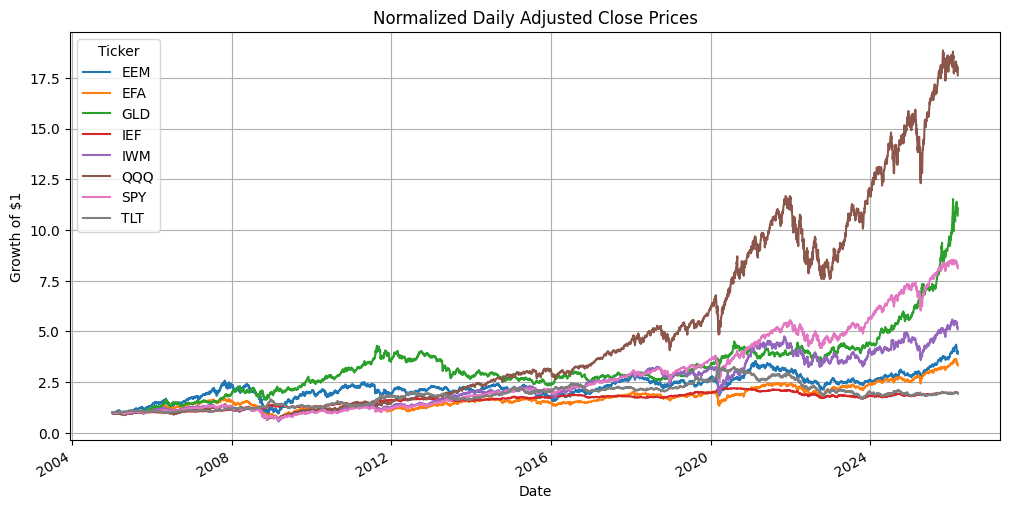

In [32]:
normalized_prices = adj_close / adj_close.iloc[0]

normalized_prices.plot(title="Normalized Daily Adjusted Close Prices")
plt.ylabel("Growth of $1")
plt.show()

## 15. Compute simple summary statistics

In this section, I compute a few basic asset-level summary statistics using monthly returns.

### What this section is doing
I estimate:
- annualized return
- annualized volatility
- a simple Sharpe ratio assuming a zero risk-free rate

### Why this matters
This gives an early sense of how the ETF universe behaves:
- which assets had the strongest growth
- which were most volatile
- which had the best return per unit of risk

### Important note
These are only rough descriptive statistics. They are not enough to judge the final strategy yet, but they are useful for understanding the assets I am working with.

### What I can change later
- I can use a nonzero risk-free rate
- I can add max drawdown, skew, kurtosis, and rolling metrics
- I can compute these on daily returns instead of monthly returns if needed

### What to expect
I should see a table summarizing return and volatility characteristics for each ETF.

In [33]:
annual_return = (1 + monthly_returns.mean()) ** 12 - 1
annual_vol = monthly_returns.std() * np.sqrt(12)
sharpe_zero_rf = annual_return / annual_vol

summary_stats = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": annual_vol,
    "Sharpe (rf=0)": sharpe_zero_rf
}).sort_values("Annual Return", ascending=False)

summary_stats

,Annual Return,Annual Volatility,Sharpe (rf=0)
Ticker,,,
QQQ,0.168707,0.180760,0.933321
GLD,0.138447,0.169246,0.818021
SPY,0.119309,0.147681,0.807887
IWM,0.106476,0.198396,0.536687
EEM,0.094836,0.208341,0.455193
EFA,0.078994,0.167863,0.470586
TLT,0.041908,0.136842,0.306250
IEF,0.035718,0.065221,0.547645


## 16. Examine the correlation structure

In this section, I look at the correlation matrix of monthly returns.

### What this section is doing
Correlation shows how similarly different ETFs move over time. This is important because the strategy benefits from assets that do not all behave the same way.

### Why this matters
If all assets were highly correlated, then ranking among them would not add much diversification value. A good tactical allocation universe should contain assets with meaningfully different behavior across market regimes.

### What I can change later
- I can compute rolling correlations instead of full-sample correlations
- I can visualize this as a heatmap later using seaborn or plotly
- I can compare different universes to see which has better diversification potential

### What to expect
I should see that equity ETFs are more correlated with each other, while Treasuries and gold may behave differently.

In [34]:
correlation_matrix = monthly_returns.corr()
correlation_matrix

Ticker,EEM,EFA,GLD,IEF,IWM,QQQ,SPY,TLT
Ticker,,,,,,,,
EEM,1.000000,0.856960,0.331031,-0.044978,0.688240,0.680813,0.732937,-0.073548
EFA,0.856960,1.000000,0.207768,-0.018426,0.772726,0.746429,0.857971,-0.057546
GLD,0.331031,0.207768,1.000000,0.311477,0.035579,0.039598,0.073885,0.232100
IEF,-0.044978,-0.018426,0.311477,1.000000,-0.143340,-0.051287,-0.077487,0.917523
IWM,0.688240,0.772726,0.035579,-0.143340,1.000000,0.786480,0.885559,-0.145562
QQQ,0.680813,0.746429,0.039598,-0.051287,0.786480,1.000000,0.909560,-0.063120
SPY,0.732937,0.857971,0.073885,-0.077487,0.885559,0.909560,1.000000,-0.090308
TLT,-0.073548,-0.057546,0.232100,0.917523,-0.145562,-0.063120,-0.090308,1.000000


## 17. Optional correlation heatmap

This is a visual version of the correlation matrix.

### What this section is doing
Instead of reading the numeric matrix directly, I create a heatmap so it is easier to spot clusters of similar assets.

### What I can change later
- I can remove this if I want to keep the notebook simpler
- I can switch to a more polished library like seaborn later
- I can make rolling heatmaps in a future notebook if I want a time-varying view

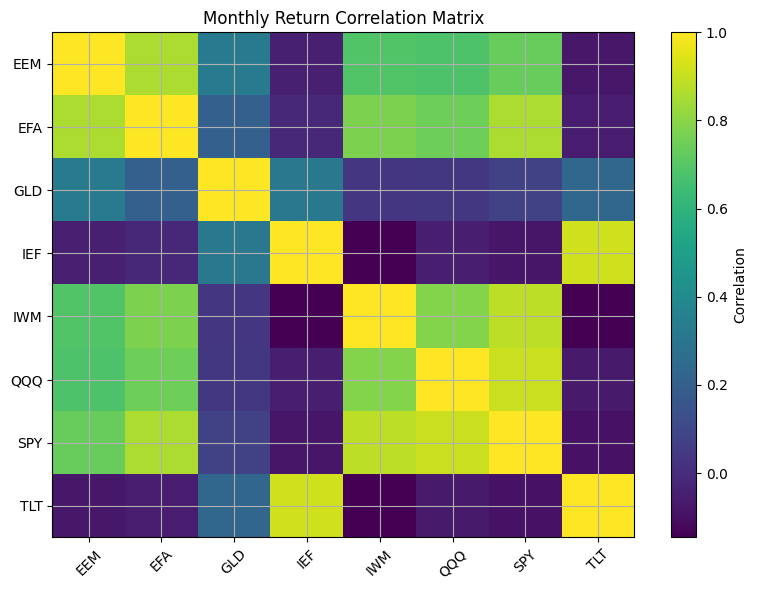

In [35]:
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("Monthly Return Correlation Matrix")
plt.tight_layout()
plt.show()

## 18. Key takeaways from this notebook

At this stage, I have completed the first step of the project data pipeline.

### What I accomplished
- defined the initial ETF universe
- downloaded historical market data
- extracted adjusted close prices
- cleaned missing values
- created daily and monthly datasets
- saved reusable CSV files
- performed basic checks on performance and correlation behavior

### What I learned from this step
This notebook helps verify that the ETF universe is broad enough to support a tactical allocation strategy. It also confirms that the data is in a format that can be used for momentum ranking, moving average filtering, and volatility targeting in later notebooks.

### What comes next
The next notebook should focus on signal research. In that notebook, I will:
- compute momentum scores
- calculate the 200-day moving average filter
- estimate rolling volatility
- test the logic for top-K selection